In [30]:
import numpy as np #import da biblitoeca numpy
import matplotlib.pyplot as plt #import da biblitoeca matplotlib

#funcao que faz e guarda as iteracoes do mapa logistico
def bif(x0, Nmax, r):
    xvec = [x0] #iniciando cm o valor inicial
    for i in range(1, Nmax+1):
         xvec.append(r*xvec[i-1]*(1-xvec[i-1])) #formula do mapa logistico
    return np.array(xvec)[-4:] #retorna apenas os 4 ultimos valores da lista de iteracoes

#funcao que faz o loop para varios valores de r
def vpl(x0, Nmax, rvec):
    output = [] #iniciando uma lista vazia
    for i in range(len(rvec)):
        output.append(bif(x0, Nmax, rvec[i])) #guardamos os resultados
    return np.array(output)


In [53]:
x0=0.5 #Valor inicial para as iteracoes
Nmax=500 #Numero de iteracoes (o ideal eh deixar um valor grande para que o mapa se estabilize antes de pegar os ultimos 4 valores)

rvec = np.array([3.3])
Nr = len(rvec)

output = vpl(x0, Nmax, rvec)[:, -2:]
output.sort(axis = 1) #Ordena os valores de cada linha do array de saida
for ir in range(Nr) :
    for ii in range(2) :
        print(f"x_{ii+1} = {output[ir][ii]:10.9f}")
    print("\n")

x_1 = 0.479427020
x_2 = 0.823603283




r =     3.4438
r_analitico =     3.4495


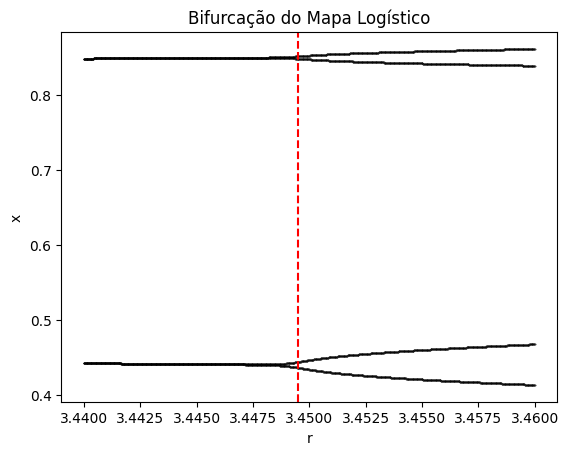

In [59]:
x0=0.5 #Valor inicial para as iteracoes
Nmax=1000 #Numero de iteracoes (o ideal eh deixar um valor grande para que o mapa se estabilize antes de pegar os ultimos 4 valores)

rvec = np.arange(3.44, 3.46, 2e-5)
Nr = len(rvec)

output = vpl(x0, Nmax, rvec)
for ir in range(Nr):
    #Aqui estou usando um metodo de "forca bruta"
    #Em que eu "varro" a lista de r e verifico se os 4 ultimos valores sao diferentes entre si
    #se forem, entao encontrei o ponto de bifurcacao
    #A funcao np.isclose() eh necessaria para evitar problemas de precisao numerica, ja que os valores sao numeros de ponto flutuante

    count = np.count_nonzero(np.isclose(output[ir], output[ir, 0], rtol = 1e-9))
    if count == 1:
        r_bif = rvec[ir]
        print(f"r = {rvec[ir]:10.4f}")
        print(rf"r_analitico = {1+np.sqrt(6):10.4f}") #valor analitico de r da bifurcacao
        break

for i in range(4):
    plt.scatter(rvec, output[:, i], s=0.1, color='black')
plt.axvline(1+np.sqrt(6), color='red', linestyle='--')
plt.xlabel('r')
plt.ylabel('x')
plt.title('Bifurcação do Mapa Logístico')
plt.show()


In [ ]:
x0=0.5 #Valor inicial para as iteracoes
Nmax=700 #Numero de iteracoes (o ideal eh deixar um valor grande para que o mapa se estabilize antes de pegar os ultimos 4 valores)

rvec = np.array([3.5])
Nr = len(rvec)

output = vpl(x0, Nmax, rvec)
output.sort(axis = 1)
for ir in range(Nr) :
    for ii in range(0, 4) :
        print(f"x_{ii+1} = {output[ir][ii]:10.9f}")
    print("\n")

x_0 = 0.382819683
x_1 = 0.500884210
x_2 = 0.826940707
x_3 = 0.874997264




r =     3.8284
r_analitico =     3.8284
x_1 = 0.159390547
x_2 = 0.512956982
x_3 = 0.956472265


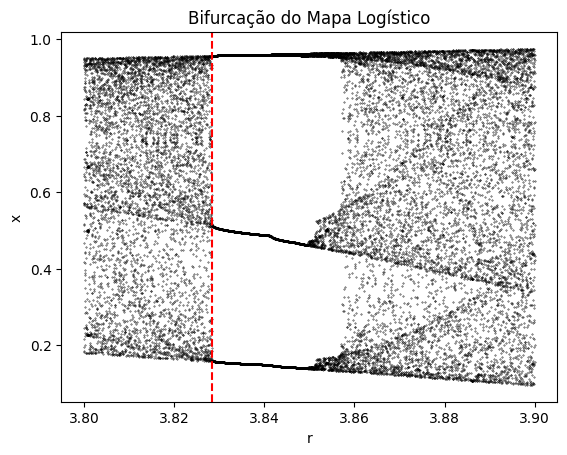

In [ ]:
x0=0.5 #Valor inicial para as iteracoes
Nmax=10000 #Numero de iteracoes (o ideal eh deixar um valor grande para que o mapa se estabilize antes de pegar os ultimos 4 valores)

rvec = np.arange(3.8, 3.9, 2e-5)
Nr = len(rvec)

output = vpl(x0, Nmax, rvec)
for ir in range(Nr):
    #Aqui estou usando um metodo de "forca bruta" novamente
    count = np.count_nonzero(np.isclose(output[ir], output[ir, 0], rtol = 1e-9))
    if count == 2:
        r_bif = rvec[ir]
        print(f"r = {rvec[ir]:10.4f}")
        print(rf"r_analitico = {1+np.sqrt(8):10.4f}") #Valor analitico da bifurcacao
        output.sort(axis = 1)
        for ii in range(0, 3):
            #Aqui uso ir+1 para garantir que estou pegando um valor correto de r
            print(f"x_{ii+1} = {output[ir+1][ii]:10.9f}")
        break

for i in range(4):
    plt.scatter(rvec, output[:, i], s=0.1, color='black')
plt.axvline(1+np.sqrt(8), color='red', linestyle='--')
plt.xlabel('r')
plt.ylabel('x')
plt.title('Bifurcação do Mapa Logístico')
plt.show()